# 03. 研究者を数値化して将来を予測する

「サイエンス・オブ・サイエンス（科学の科学）」は、論文・引用・著者といった大規模データを使って**科学そのものを定量的に研究する**分野です。このノートブックはその中でも、「**1人の研究者**をどう数値で測り、キャリア初期のデータから将来をどこまで予測できるか」を扱います。

主な出発点は 01 で作った `data/works/bacteria/paper_authors.parquet`（**1行 = 1著者 × 1論文** のテーブル）です。途中で論文本文情報を足すために `works.parquet`、ランダム著者の全業績を見るために `data/career/paper_authors.parquet` も読み込みます。

## このノートブックの流れ
1. **リーダーボードと H-index 分布**（§2）: 論文数・総被引用数・H-index などの指標で研究者を測り、4つの指標の長所と弱点を比べます。日本の研究者・国別比較・生産性 vs インパクト・活動要約（GPT / TF-IDF）も扱います。
2. **ランダムインパクトルール**（§3）: 「研究者の最大ヒット論文は、キャリアのいつ出るのか？」— Sinatra et al. (2016) の有名な経験則を、**トピック内の論文（§3-1）** と **完全ランダムな著者の全業績（§3-2）** の2通りで検証します。
3. **初期キャリア → 将来 H-index の予測**（§4–5）: デビュー数年間の特徴量から将来の H-index を Random Forest（機械学習の一種）で予測し、どの初期指標が効くのかを見ます。

> **注意**: `cited_by_count` は「データ取得時点」の累積被引用数で、過去の各時点での引用数ではありません。厳密な将来予測には各時点のスナップショットが必要です。ここでは相関構造を見る教材として扱います。


## 準備：ライブラリとデータの読み込み

次の2つのセルは環境準備です。①必要なライブラリの読み込みとデータの自動取得（Colab ではインストールとリポジトリ取得も自動）、②解析対象データセットの選択（`bacteria`＝バクテリオファージ / `qc`＝量子）と、この後くり返し使う **H-index を計算する関数** の定義を行います。上から順に実行すれば、Colab でも手元の Jupyter でも動きます。

In [ ]:
# === セットアップ（このセルを最初に実行）===
# ローカル(Jupyter): 依存の確認と作業ディレクトリの調整のみ。
# Google Colab   : 依存インストール＋リポジトリ取得も自動で行う。
import os, sys
os.environ['OPENAI_API_KEY'] = 'sk-xxxxx' 

# データを変更して他ノートと共有・永続化したい人だけ True に（Google Drive をマウントします）。
# False（既定）なら使い捨てランタイム内で完結し、必要データは GitHub Release から取得します（権限プロンプト不要・完全ワンクリック）。
USE_DRIVE = False

if 'google.colab' in sys.modules:
    !pip -q install requests pandas pyarrow numpy matplotlib scikit-learn scipy powerlaw networkx igraph leidenalg umap-learn gender-guesser iso4 nltk openai
    if USE_DRIVE:
        from google.colab import drive
        drive.mount('/content/drive')                      # Trueにした人だけ Drive 権限を承認（各自のDrive・同名でOK）
        BASE = '/content/drive/MyDrive/sciscitutorial'     # ノート間・セッション間でデータを永続共有
    else:
        BASE = '/content/sciscitutorial'                   # 使い捨てランタイム内。権限不要（データはRelease/APIから）
    if not os.path.exists(f'{BASE}/.git'):
        !git clone -q https://github.com/asatani/sciscitutorial.git {BASE}
    os.chdir(BASE)

# code/ から起動した場合はプロジェクトルート（data/ がある場所）へ移動する。
if os.path.basename(os.getcwd()) == 'code':
    os.chdir('..')

# 事前計算済みデータが無ければ GitHub Release から取得し data/ 以下に展開する。
# works=対象トピックの論文, career=03 §3-2 用のランダム著者, supplementary=06(DI)用のエッジリスト。
def ensure_data(name, works=False, career=False, supplementary=False):
    import urllib.request, zipfile
    RELEASE = 'https://github.com/asatani/sciscitutorial/releases/download/data-v1'
    needs = []
    if works:         needs.append((f'data/works/{name}', f'works_{name}.zip'))
    if career:        needs.append(('data/career', 'career.zip'))
    if supplementary: needs.append(('data/supplementary', 'supplementary.zip'))
    os.makedirs('data', exist_ok=True)
    for path, asset in needs:
        if os.path.exists(path):
            continue
        print('downloading', asset, '...')
        zip_path = f'data/{asset}'
        urllib.request.urlretrieve(f'{RELEASE}/{asset}', zip_path)
        with zipfile.ZipFile(zip_path) as z:
            z.extractall('data')
        os.remove(zip_path)


In [2]:
import os, time
import numpy as np
import pandas as pd
import requests
from scipy import stats
import matplotlib.pyplot as plt
plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'font.size': 11, 'axes.titlesize': 12, 'axes.titleweight': 'bold',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.25, 'legend.frameon': False,
    'axes.prop_cycle': plt.cycler(color=['#E24A33', '#348ABF', '#988ED5', '#777777', '#FBC15E', '#8EBA42']),
})
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
pd.set_option('display.max_columns', 100)

# --- データセット選択（'bacteria'=T11048 / 'qc'=T10020）---
NAME      = 'bacteria'              # ← 'qc' に変えれば量子データセットに切替
DATA_DIR  = f'data/works/{NAME}'
OUT_DIR   = f'output/{NAME}'
MAILTO    = 'asatani@gmail.com'
GPT_MODEL = 'gpt-5.4-mini'          # 研究者の活動をGPTで要約する際のモデル（§2-3で使用）
ensure_data(NAME, works=True, career=True)   # works と career（§3-2用）を取得
os.makedirs(OUT_DIR, exist_ok=True)

# h-index: 「被引用数が h 以上の論文が h 本ある」を満たす最大の h。引用リストから計算する。
def h_index(citations):
    c = np.sort(np.asarray(citations))[::-1]         # 被引用の多い順に並べる
    return int((c >= np.arange(1, len(c) + 1)).sum())


## 1. データを読み込む

01 で保存した「1行 = 1著者 × 1論文」のテーブルを読み込みます。このあとの分析で計算できるように、出版年と被引用数を数値型に整え、1本の論文に載っている著者数から **共著者数（自分以外の人数）** も作っておきます。

In [3]:
# 01が保存した「1行=1著者×1論文」テーブルを読み込む。
paper_authors = pd.read_parquet(f'{DATA_DIR}/paper_authors.parquet')
# 出版年・被引用数を数値に変換（変換不能な値は欠損に→引用は0埋め）し、年か著者IDが欠けた行は捨てる。
paper_authors['publication_year'] = pd.to_numeric(paper_authors['publication_year'], errors='coerce')
paper_authors['cited_by_count'] = pd.to_numeric(paper_authors['cited_by_count'], errors='coerce').fillna(0)
paper_authors = paper_authors.dropna(subset=['publication_year', 'author_id'])
# 同一著者が同じ論文に複数回現れる行を1件に集約する。
# （OpenAlexは所属機関ごとに著者を重複計上することがあり、放置すると h-index が論文数を超える等の不整合が出る）
paper_authors = paper_authors.drop_duplicates(['author_id', 'work_id'])
# 共著者数 = 同じ論文(work_id)に載っている著者数 - 1（自分を除く）。groupby.transformで各行に展開。
paper_authors['coauthor_count'] = paper_authors.groupby('work_id')['author_id'].transform('size') - 1

print('rows:', len(paper_authors), '/ unique authors:', paper_authors['author_id'].nunique())
print('year range:', int(paper_authors['publication_year'].min()), '-', int(paper_authors['publication_year'].max()))
paper_authors.head()


rows: 385645 / unique authors: 192664
year range: 1833 - 2024


,work_id,title,publication_year,cited_by_count,fwci,author_id,author_name,author_position,institutions,countries,coauthor_count
0,https://openalex.org/W2100837269,Cleavage of Structural Proteins during the Ass...,1970,251645,276.1411,https://openalex.org/A5030122660,Ulrich K. Laemmli,first,[I170203145],[GB],0
1,https://openalex.org/W2138270253,DNA sequencing with chain-terminating inhibitors,1977,69307,92.0422,https://openalex.org/A5114007683,Frederick Sanger,first,"[I170203145, I90344618]",[GB],2
2,https://openalex.org/W2138270253,DNA sequencing with chain-terminating inhibitors,1977,69307,92.0422,https://openalex.org/A5035256244,S. Nicklen,middle,"[I170203145, I90344618]",[GB],2
3,https://openalex.org/W2138270253,DNA sequencing with chain-terminating inhibitors,1977,69307,92.0422,https://openalex.org/A5110225174,Alan Coulson,last,"[I170203145, I90344618]",[GB],2
4,https://openalex.org/W2028622989,Improved M13 phage cloning vectors and host st...,1985,15166,845.2060,https://openalex.org/A5083744626,Celeste Yanisch-Perron,first,[I130238516],[US],2


**結果の見方**: このトピック（バクテリオファージ＝細菌に感染するウイルス）には、のべ **385,645 行**（著者×論文）、**192,664 人** のユニークな著者が含まれ、出版年は **1833〜2024 年** にわたります。表の各行は「ある著者の、ある論文」で、被引用数（`cited_by_count`）・著者の並び順（`author_position`: first / middle / last）・所属国（`countries`）などが並びます。これが以降すべての分析の材料です。

## 2. トップ研究者のリーダーボードと H-index 分布

まず著者ごとに **論文数・総被引用数・H-index** を集計して、「リーダーボード（順位表）」を作ります。ここでの H-index はサンプル内（このトピックの論文だけ）で計算した値です。あわせて、H-index の分布と上位20人を可視化します。

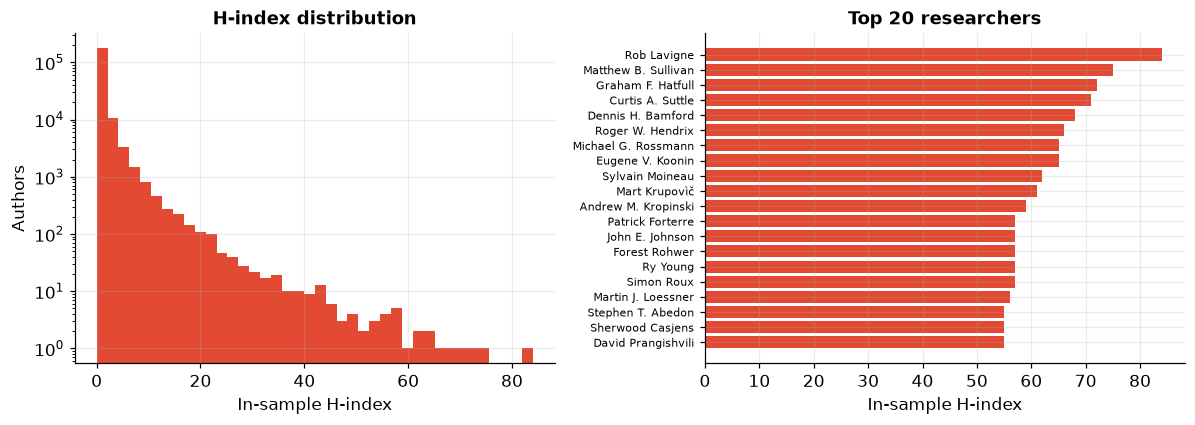

In [4]:
# 著者ごとに集計してリーダーボード authors_df を作る。
# papers=書いた論文数(work_idのユニーク数), total_citations=被引用の合計, h_index=著者の引用リストから計算。
authors_df = paper_authors.groupby('author_id').agg(
    author_name=('author_name', 'first'),
    papers=('work_id', 'nunique'),
    total_citations=('cited_by_count', 'sum'))
authors_df['h_index'] = paper_authors.groupby('author_id')['cited_by_count'].apply(h_index)
authors_df = authors_df.sort_values('h_index', ascending=False).reset_index()   # H-index降順に並べる

# 左: H-index の分布（縦軸log=少数の突出を見やすく）, 右: 上位20人の横棒グラフ。
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(authors_df['h_index'], bins=40, color='#E24A33'); axes[0].set_yscale('log')
axes[0].set_title('H-index distribution'); axes[0].set_xlabel('In-sample H-index'); axes[0].set_ylabel('Authors')
top20 = authors_df.head(20).iloc[::-1]                    # 上位20人（横棒は下→上に積むので順序を反転）
axes[1].barh(top20['author_name'], top20['h_index'], color='#E24A33')
axes[1].set_title('Top 20 researchers'); axes[1].set_xlabel('In-sample H-index'); axes[1].tick_params(axis='y', labelsize=7)
fig.tight_layout(); fig.savefig(f'{OUT_DIR}/03_top_researchers.pdf'); plt.show()


**結果の見方**: 左のヒストグラム（縦軸は対数）を見ると、H-index の分布は**強く右に歪んで**います。大多数の研究者は H-index が小さく、ごく一部だけが非常に高い — 科学の生産性・影響力によく見られる「べき則的」な偏りです。右の棒グラフはこのトピックでの H-index 上位20人で、バクテリオファージ研究の中心人物が並びます。

### 2-1. 研究者をどう測るか — 4つの指標の比較

参照: ScisciJP `tutorial_jp` 4-H-index。研究者の業績を1つの数字で測ろうとすると、指標ごとに見えるものと弱点が変わります。

| 指標 | 測れるもの | 弱点 |
|---|---|---|
| 発表論文数 | 生産力（どれだけ書いたか） | 影響力を無視（多産でも引用ゼロかも） |
| 総被引用数 | 影響力の総量 | 1本の大ヒットに引きずられる |
| 平均被引用数 | 1本あたりの質 | 多産な人が不利／少数論文だと不安定 |
| **h-index** | 量と質のバランス・**持続的な**影響 | 分野差・キャリア長に依存、上限は論文数 |

**h-indexの定義**: 「被引用数が $h$ 以上の論文が $h$ 本あり、それ以外の論文の被引用数がすべて $h$ 未満」となる最大の $h$。次の stem plot では、被引用降順に並べた論文に **45°線（被引用=順位）** を重ね、その線を上回る最大順位が h-index になります。

### 2-2. トップ研究者の h-index 曲線（stem plot）

参照: ScisciJP `tutorial_jp` 4-H-index。リーダーボード1位の研究者の論文を、**被引用数の多い順**に並べて棒（stem plot）で描きます。そこに **45°線（被引用数 = 順位）** を重ねると、「被引用数 ≥ 順位」を満たす最大の順位が h-index になる、という定義を目で確認できます。

Rob Lavigne: 320 papers, h-index=84


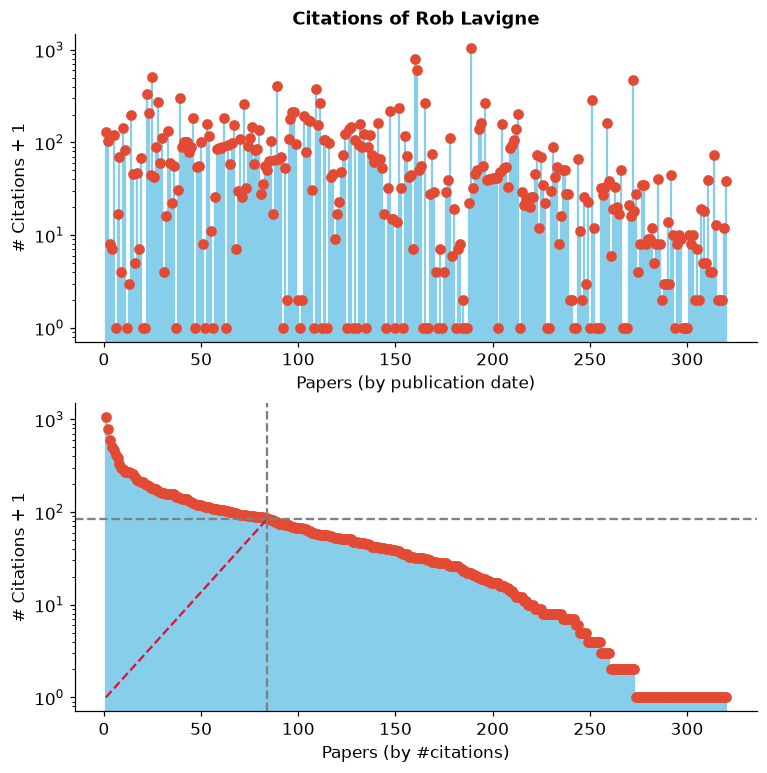

In [5]:
# リーダーボード1位の研究者について、H-index を stem plot で図解する。
top_author = authors_df.iloc[0]
cites = (paper_authors[paper_authors['author_id'] == top_author['author_id']]
         .drop_duplicates('work_id').sort_values('publication_year')['cited_by_count'].to_numpy())
cites_sorted = np.sort(cites)[::-1]                       # 被引用の多い順
h = int((cites_sorted >= np.arange(1, len(cites_sorted) + 1)).sum())
print(f"{top_author['author_name']}: {len(cites)} papers, h-index={h}")

fig, axes = plt.subplots(2, 1, figsize=(8, 8))
for ax, c, xlab in [(axes[0], cites, 'Papers (by publication date)'),
                    (axes[1], cites_sorted, 'Papers (by #citations)')]:
    markerline, stemlines, _ = ax.stem(np.arange(1, len(c) + 1), c + 1, basefmt=' ')
    plt.setp(stemlines, color='skyblue')
    ax.set_yscale('log'); ax.set_xlabel(xlab); ax.set_ylabel('# Citations + 1'); ax.grid(False)
# 下段に 45°線（被引用=順位）と h-index のガイド線を重ねる。被引用>=順位 を満たす最大順位が h。
xlim, ylim = axes[1].get_xlim(), axes[1].get_ylim()
axes[1].plot([1, h], [1, h], '--', color='crimson')
axes[1].plot(xlim, [h, h], '--', color='gray'); axes[1].plot([h, h], ylim, '--', color='gray')
axes[1].set_xlim(xlim); axes[1].set_ylim(ylim)
axes[0].set_title(f"Citations of {top_author['author_name']}")
fig.savefig(f'{OUT_DIR}/03_top_researcher_hindex.pdf'); plt.show()


**結果の見方**: 上段は出版順、下段は被引用数の多い順に並べた論文です。下段で、赤い45°線（被引用数 = 順位）より論文の点が**上にある**うちは「その順位までの論文がすべて順位以上の被引用を持つ」ことを意味します。点が45°線を下回る手前の順位が h-index で、灰色のガイド線がその値を示します。1位の研究者は多数の論文それぞれが十分に引用されており、大きな h-index を持つことが読み取れます。

### 2-3. トップ研究者の代表論文を GPT で要約する

トップ研究者の代表論文（被引用数の多い順に、最近5件と昔5件）を取り出し、その一覧を大規模言語モデル（GPT）に渡して「この人の研究テーマの中心と、その変遷」を短い日本語で解説してもらいます。`OPENAI_API_KEY` に実際のキーが設定されていれば要約が出力されます。キーを使わない場合は、セットアップセルのダミー値を設定しない状態にしておくと、組み立てたプロンプト（指示文）だけを表示します。

In [6]:
# --- 2-3. トップ研究者の代表論文をGPTで解説（最近5件 / 昔5件）---
# OpenAI APIキーは環境変数 OPENAI_API_KEY から読み込みます（未設定ならプロンプトだけ表示）。
# os.environ['OPENAI_API_KEY'] = 'sk-...'
author_id = authors_df.iloc[0]['author_id']              # トップ研究者（任意の行に変更可）
author_name = authors_df.iloc[0]['author_name']
papers = paper_authors[paper_authors['author_id'] == author_id].drop_duplicates('work_id')

def top5_titles(df):
    top = df.nlargest(5, 'cited_by_count')
    return '\n'.join(f"- {r.title} ({int(r.publication_year)}, {int(r.cited_by_count)}c)" for r in top.itertuples())

recent5 = top5_titles(papers[papers['publication_year'] >= 2020])
old5 = top5_titles(papers[papers['publication_year'] < 2020])
prompt = (f"研究者「{author_name}」の代表論文です。\n\n【最近のトップ引用5件】\n{recent5}\n\n"
          f"【昔のトップ引用5件】\n{old5}\n\n"
          "この研究者の研究テーマの中心と、昔から最近への変遷を日本語200字程度で簡潔に解説してください。")

if os.getenv('OPENAI_API_KEY'):
    from openai import OpenAI
    resp = OpenAI().chat.completions.create(model=GPT_MODEL, messages=[{"role": "user", "content": prompt}])
    print(resp.choices[0].message.content)
else:
    print('OPENAI_API_KEY 未設定のためスキップします。組み立てたプロンプト:\n')
    print(prompt)


Rob Lavigne氏の中心テーマは、**バクテリオファージの分類・ゲノム解析・作用機構の解明**と、**それを基盤にしたファージ療法／バイオコントロールの応用**です。昔は未培養ウイルスの分類やMIUViG、ファージ構造・標的機構など基礎寄りの研究が中心でしたが、近年はICTVの分類更新を主導しつつ、耐性菌感染へのファージ＋抗菌薬併用療法や植物保護など、臨床・農業へ応用範囲を広げています。


**結果の見方**: API キーを設定していれば、この研究者が「何を研究してきた人か」「昔から最近でテーマがどう動いたか」を短くまとめた解説文が返ります（例では Rob Lavigne について、ファージの分類・ゲノム解析から、近年の耐性菌へのファージ治療・応用研究への広がりが要約されています）。キーが未設定でもプロンプト（GPTへの指示文）が表示されるので、どんな入力から要約が作られるかを追えます。§2-7 では同じ「活動要約」を、LLMを使わず統計的手法（TF-IDF）で行います。

### 2-4. 日本の研究機関に所属する研究者に絞る

各著者の**主所属国**（全論文に登場する国の最頻値）が日本（`JP`）の研究者だけのリーダーボードです。「共著で一度でもJPが出る人」まで含めると主に海外拠点の研究者が混ざるため、最頻値で「主に日本拠点」を近似します。`main_country` を変えれば他国にも応用できます。

主所属が日本の著者: 7456人 / 全体 192664人


,author_name,h_index,papers,total_citations
62,Hiroyuki Ogata,39,103,9088
136,Yuji Tomaru,30,78,2630
151,Keizo Nagasaki,28,73,2748
153,Yasunori Tanji,28,60,2850
194,Jumpei Uchiyama,26,59,3175
207,Shigenobu Matsuzaki,25,60,2624
232,Fumio Arisaka,24,94,3271
304,Hisao Fujisawa,22,45,1189
352,Kazuhiko Miyanaga,21,49,1478
354,Takashi Yamada,20,51,1425


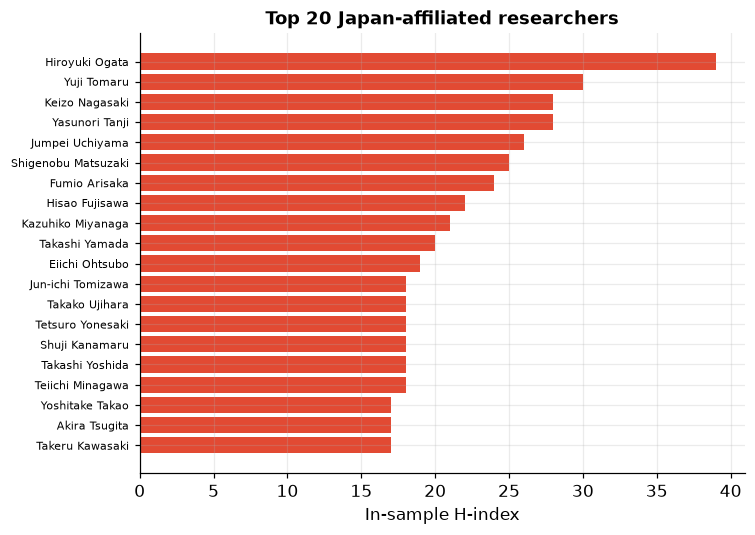

In [7]:
from collections import Counter
# 主所属国 = その著者の全論文に登場する国の最頻値（共著で一度だけJPが出る人を除くための近似）。
def main_country(country_lists):
    counter = Counter(c for arr in country_lists for c in (arr if isinstance(arr, (list, np.ndarray)) else []))
    return counter.most_common(1)[0][0] if counter else None
authors_df['main_country'] = authors_df['author_id'].map(
    paper_authors.groupby('author_id')['countries'].apply(main_country))

authors_jp = authors_df[authors_df['main_country'] == 'JP']
print(f'主所属が日本の著者: {len(authors_jp)}人 / 全体 {len(authors_df)}人')
display(authors_jp.head(15)[['author_name', 'h_index', 'papers', 'total_citations']])

fig, ax = plt.subplots(figsize=(7, 5))
top = authors_jp.head(20).iloc[::-1]
ax.barh(top['author_name'], top['h_index'], color='#E24A33')
ax.set_title('Top 20 Japan-affiliated researchers'); ax.set_xlabel('In-sample H-index')
ax.tick_params(axis='y', labelsize=7)
fig.tight_layout(); fig.savefig(f'{OUT_DIR}/03_top_researchers_japan.pdf'); plt.show()


**結果の見方**: 各著者の「主所属国」を、その人の全論文に出てくる国の**最頻値**で近似し、それが日本（`JP`）の研究者だけを抜き出しています（共著で一度だけ日本が登場する海外研究者を除くための工夫）。表と棒グラフに、このトピックで主に日本を拠点とする研究者の H-index 上位が並びます。`main_country` の判定を変えれば、他国にも同じ分析を適用できます。

### 2-5. 生産性 vs インパクト（散布図）

論文数（生産性）とH-index（持続的インパクト）は別物です。両対数で散布し、**h ≤ 論文数**の上限線を重ねると、右下＝多作だが低インパクト、左上＝少数精鋭、という両極が読み取れます。`eff = h / papers`（効率）で両極を注記しています。

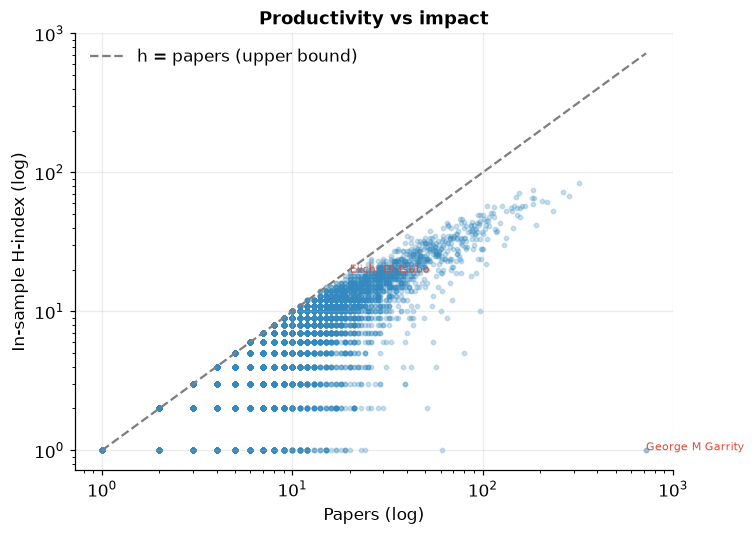

In [8]:
# 論文数（生産性）と H-index（持続的インパクト）を両対数で散布する。
authors_df['efficiency'] = authors_df['h_index'] / authors_df['papers']
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(authors_df['papers'], authors_df['h_index'], s=8, alpha=0.25, color='#348ABF')
lim = np.array([1, authors_df['papers'].max()])
ax.plot(lim, lim, '--', color='gray', label='h = papers (upper bound)')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Papers (log)'); ax.set_ylabel('In-sample H-index (log)')
ax.set_title('Productivity vs impact'); ax.legend()
# 両極を注記: 最も多作な人 と 少数精鋭（papers>=20 で efficiency=h/papers が最大の人）
for _, r in pd.concat([authors_df.nlargest(1, 'papers'),
                       authors_df[authors_df['papers'] >= 20].nlargest(1, 'efficiency')]).iterrows():
    ax.annotate(r['author_name'], (r['papers'], r['h_index']), fontsize=7, color='#E24A33')
fig.tight_layout(); fig.savefig(f'{OUT_DIR}/03_productivity_vs_impact.pdf'); plt.show()


**結果の見方**: 横軸が論文数（生産性）、縦軸が H-index（持続的インパクト）で、どちらも対数目盛です。灰色の破線 `h = papers` は理論的な上限（すべての論文が h 回以上引用されても、h は論文数を超えられない）。点がこの線の近く＝**少数精鋭**（左上寄り）、線から大きく下に離れる＝**多作だが1本あたりのインパクトは低い**（右下寄り）。たくさん書くことと影響力が別物であることが読み取れます。注記された2人が両極の例です。

### 2-6. 国別トップ研究者の比較

`main_country` ごとに、現役層（`papers ≥ 3`・著者100人以上の国）の**中央値H-index**と**トップH-index**を並べます。被引用は分野・国の規模・サンプリングに左右されるので、これは“純粋な実力比較”ではなく、**このトピック内での分布の違い**として読んでください。

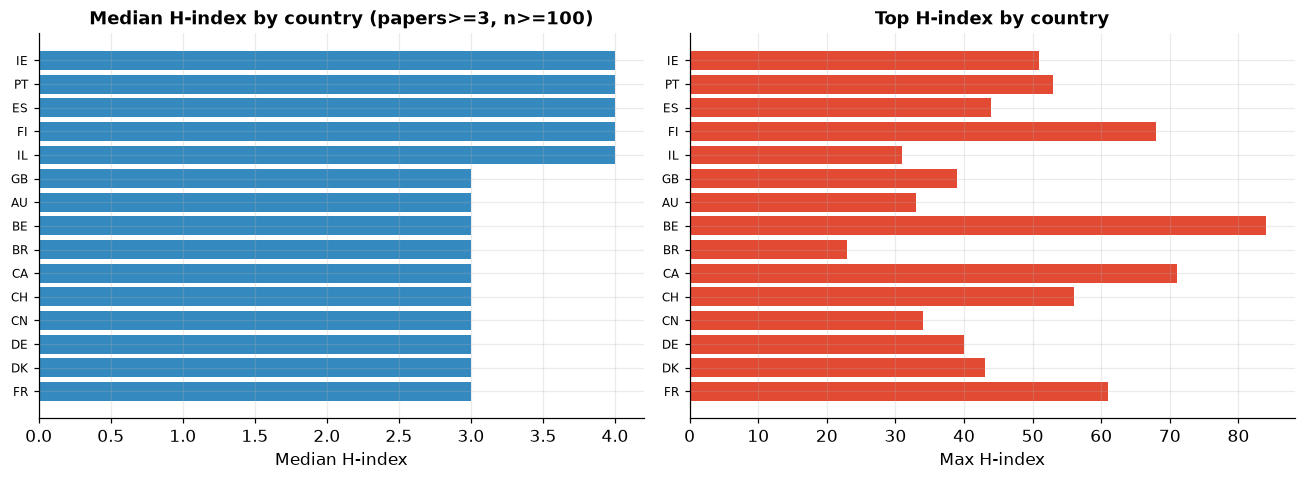

In [9]:
# main_country は §2-4 で計算済み。現役層(papers>=3)で国別に集計する。
active = authors_df[authors_df['papers'] >= 3]
grp = active.groupby('main_country')['h_index']
country = pd.DataFrame({'median_h': grp.median(), 'top_h': grp.max(), 'authors': grp.size()})
country = country[country['authors'] >= 100].sort_values('median_h').tail(15)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].barh(country.index, country['median_h'], color='#348ABF')
axes[0].set_title('Median H-index by country (papers>=3, n>=100)'); axes[0].set_xlabel('Median H-index')
axes[1].barh(country.index, country['top_h'], color='#E24A33')
axes[1].set_title('Top H-index by country'); axes[1].set_xlabel('Max H-index')
for ax in axes:
    ax.tick_params(axis='y', labelsize=8)
fig.tight_layout(); fig.savefig(f'{OUT_DIR}/03_country_comparison.pdf'); plt.show()


**結果の見方**: 現役層（論文3本以上）に絞り、著者が100人以上いる国だけを対象に、**中央値 H-index**（左）と**トップ H-index**（右）を国別に並べました。中央値は「その国の“平均的な”研究者」、トップは「突出した1人」を表します。ただし被引用数は分野・国の規模・データの取り方に強く左右されるため、これは実力の純粋比較ではなく、**このトピック内での分布の違い**として読んでください。

### 2-7. トップ研究者の活動を要約する（アブストラクト＋代表論文）

リーダーボード上位 `TOP_N` 人について、`works.parquet` の**アブストラクト**を結合し、活動を1行に要約した表を作ります。

- **keywords**: 各研究者のアブストラクトを束ねた文書に TF-IDF をかけ、その人を特徴づける語を抽出（上位者に広く共通する一般語は `max_df` で除外、MathMLタグも除去）。
- **top past / top recent**: 被引用数トップ論文を **過去（< `RECENT_FROM`）** と **最近（≥ `RECENT_FROM`）** に分けて表示。研究の主軸が時代でどう動いたかが分かります。
- **main_topic**: OpenAlex の `primary_topic` の最頻値。

LLMによる要約ではなく統計的キーフレーズですが、「何を研究してきた人か」を俯瞰するには十分です。表は `output/03_researcher_activity_summary.csv` にも保存します。

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction import text as sktext

TOP_N, RECENT_FROM = 10, 2020
# 抄録を使うので works.parquet（1行=1論文）を読み、work_id で著者テーブルに結合する。
works_df = pd.read_parquet(f'{DATA_DIR}/works.parquet')[
    ['id', 'title', 'publication_year', 'cited_by_count', 'primary_topic', 'abstract']
].rename(columns={'id': 'work_id'})

top_authors = authors_df.head(TOP_N)['author_id'].tolist()
author_papers = (paper_authors[paper_authors['author_id'].isin(top_authors)]
                 [['author_id', 'author_name', 'work_id']].drop_duplicates()
                 .merge(works_df, on='work_id', how='left'))

# 特徴語: 各研究者のアブストラクトを1文書に束ねて TF-IDF（全員共通の語は max_df で除外, MathMLタグも除去）
JUNK = {'mml', 'math', 'xmlns', 'mi', 'mo', 'mn', 'msub', 'msup', 'mrow',
        'mfrac', 'mtext', 'mathml', 'annotation', 'semantics'}
stop_words = list(sktext.ENGLISH_STOP_WORDS | JUNK)
docs = [' '.join(author_papers[author_papers['author_id'] == a]['abstract'].dropna().astype(str)) for a in top_authors]
tfidf = TfidfVectorizer(stop_words=stop_words, ngram_range=(1, 2), min_df=1, max_df=0.7,
                        token_pattern=r'(?u)\b[a-zA-Z][a-zA-Z-]{2,}\b')
tfidf_matrix = tfidf.fit_transform(docs)
vocab = np.array(tfidf.get_feature_names_out())
keywords = {a: ', '.join(vocab[tfidf_matrix[i].toarray().ravel().argsort()[::-1][:6]])
            for i, a in enumerate(top_authors)}

def top_paper(df):
    if len(df) == 0 or df['cited_by_count'].isna().all():
        return '—'
    r = df.loc[df['cited_by_count'].idxmax()]
    return f"{str(r['title'])[:45]} ({int(r['publication_year'])}, {int(r['cited_by_count'])}c)"

rows = []
for a in top_authors:
    g = author_papers[author_papers['author_id'] == a]
    rows.append({
        'researcher': g['author_name'].iloc[0],
        'h': int(authors_df.loc[authors_df['author_id'] == a, 'h_index'].iloc[0]),
        'papers': g['work_id'].nunique(),
        'main_topic': g['primary_topic'].mode().iloc[0] if g['primary_topic'].notna().any() else '—',
        'keywords (TF-IDF)': keywords[a],
        f'top past (<{RECENT_FROM})': top_paper(g[g['publication_year'] < RECENT_FROM]),
        f'top recent (>={RECENT_FROM})': top_paper(g[g['publication_year'] >= RECENT_FROM]),
    })
researcher_summary = pd.DataFrame(rows)
pd.set_option('display.max_colwidth', 60)
display(researcher_summary)
researcher_summary.to_csv(f'{OUT_DIR}/03_researcher_activity_summary.csv', index=False)


,researcher,h,papers,main_topic,keywords (TF-IDF),top past (<2020),top recent (>=2020)
0,Rob Lavigne,84,320,Bacteriophages and microbial interactions,"aeruginosa, therapy, phage therapy, endolysins, pseudomo...","Taxonomic assignment of uncultivated prokaryo (2019, 1051c)","Abolishment of morphology-based taxa and chan (2023, 469c)"
1,Matthew B. Sullivan,75,184,Bacteriophages and microbial interactions,"amgs, metagenomes, carbon, ocean, sags, viromics","VirSorter: mining viral signal from microbial (2015, 1212c)","VirSorter2: a multi-classifier, expert-guided (2021, 1331c)"
2,Graham F. Hatfull,72,263,Bacteriophages and microbial interactions,"mycobacterium, mycobacteriophages, mycobacteriophage, sm...","Engineered bacteriophages for treatment of a (2019, 1405c)","Phage therapy: From biological mechanisms to (2023, 767c)"
3,Curtis A. Suttle,71,155,Bacteriophages and microbial interactions,"coastal, ocean, phytoplankton, genetic resources, waters...","Marine viruses — major players in the global (2007, 3248c)","Eukaryotic virus composition can predict the (2020, 94c)"
4,Dennis H. Bamford,68,285,Bacteriophages and microbial interactions,"google, pubmed, scholar, google scholar, scopus google, ...","What does structure tell us about virus evolu (2005, 394c)","Lysis Physiology of Pseudomonas aeruginosa In (2024, 6c)"
5,Roger W. Hendrix,66,150,Bacteriophages and microbial interactions,"mycobacteriophages, mycobacteriophage, groe, prohead, he...","Evolutionary relationships among diverse bact (1999, 1121c)","Structural basis of DNA packaging by a ring-t (2022, 14c)"
6,Michael G. Rossmann,65,186,Bacteriophages and microbial interactions,"dna-packaging, nuclease, portal, vitro dna, atpase nucle...","Structure of the bacteriophage φ29 DNA packag (2000, 518c)","Structural morphing in a symmetry-mismatched (2020, 44c)"
7,Eugene V. Koonin,65,181,Bacteriophages and microbial interactions,"ncldv, defense, giant, giant viruses, virome, nucleocyto...","Minimum Information about an Uncultivated Vir (2018, 790c)","Diverse enzymatic activities mediate antivira (2020, 664c)"
8,Sylvain Moineau,62,205,Bacteriophages and microbial interactions,"lactococcal, rbp, lactis, lactococcus, google, lactococc...","CRISPR Provides Acquired Resistance Against V (2007, 6293c)","Phage diversity, genomics and phylogeny (2020, 972c)"
9,Mart Krupovìč,61,218,Bacteriophages and microbial interactions,"lipids, nucleocytoviricota, virome, hyperthermophilic, t...","Taxonomic assignment of uncultivated prokaryo (2019, 1051c)","Abolishment of morphology-based taxa and chan (2023, 469c)"


**結果の見方**: 上位10人それぞれについて、アブストラクトを束ねて TF-IDF にかけた**特徴語**、`primary_topic` の最頻値、被引用トップ論文を「過去（<2020）」「最近（≥2020）」に分けて1行にまとめています。全員の `main_topic` は "Bacteriophages and microbial interactions"（バクテリオファージと微生物間相互作用）で共通する一方、特徴語を見ると Rob Lavigne は phage therapy（ファージ療法）、Matthew B. Sullivan は ocean / metagenomes（海洋・メタゲノム）など、**同じトピック内でも各研究者の専門が違う**ことが分かります。LLMを使わなくても統計だけで「何を研究してきた人か」を俯瞰できます（一部に "google, scholar" のような手法説明由来の語が混じるのは統計的手法の限界です。表は CSV にも保存されます）。

## 3. ランダムインパクトルール（最大ヒットの出現タイミング）

Sinatra et al. (2016) の **random impact rule**: 研究者の**最大ヒット論文が出るタイミング**は、論文を出版順に並べた系列の中で**ほぼランダム（一様分布）**という経験則です。「大器晩成型」も「若くしてピーク型」も特別ではなく、最高傑作はキャリアのどこにでも等確率で現れる、という主張です。

各著者について「最大ヒットが何本目か」を相対順位 `N*/N`（おおよそ 0=処女作, 1=最終作）で表し、その分布が**一様分布**に近いかを **KS検定** で確かめます。以下の2通りで見ます。

- **§3-1 トピック内の論文だけ（部分キャリア版）**: 手元の `paper_authors` をそのまま使う手軽な版。ただし1トピック限定なので各著者は部分キャリアで、ヒットはやや前半に偏りがちです。
- **§3-2 完全ランダムな著者の全業績（完全版）**: OpenAlexから著者をランダム抽出して全業績を取得する、元論文に忠実な版。

### 3-1. トピック内の論文で見る（部分キャリア版）

**インパクトの測り方**: 生の被引用数は古い論文ほど大きくなる（蓄積年数バイアス）ので、そのまま最大値を取ると最大ヒットが前半に偏ります。そこで各論文のインパクトには `fwci` を使い、さらに**同じ出版年コホート内のパーセンタイル**に変換してから最大ヒットを選びます。


In [11]:
MIN_PAPERS = 20
YEAR_MIN, YEAR_MAX = 1980, 2020      # %ile化で蓄積差を吸収するので終端は緩めに

# インパクトは「同じ出版年コホート内での FWCI パーセンタイル(0〜1)」で測る。
# 年内で順位化し、データ取得時点や出版年による残差的な差を抑えてから最大ヒットを選ぶ。
unique_works = paper_authors.drop_duplicates('work_id').copy()
unique_works['fwci'] = unique_works['fwci'].fillna(0)
cite_pct = unique_works.groupby('publication_year')['fwci'].rank(pct=True)
cite_pct_by_work = unique_works.assign(cite_pct=cite_pct).set_index('work_id')['cite_pct']

# 各著者について、最大ヒット（%ile最大の論文）の出版順の相対位置が一様分布かを検証する。
peak_rank = []                       # 各著者の最大ヒット位置（おおよそ 0=処女作, 1=最終作）
rng = np.random.default_rng(0)
for _, career in paper_authors.groupby('author_id'):
    career = career.drop_duplicates('work_id').dropna(subset=['publication_year'])
    if len(career) < MIN_PAPERS:
        continue
    # 同年内の順序依存を消すため、シャッフルしてから年で安定ソートする
    career = career.iloc[rng.permutation(len(career))].sort_values('publication_year', kind='stable')
    years = career['publication_year'].to_numpy()
    if years.min() < YEAR_MIN or years.max() > YEAR_MAX:     # 部分キャリア・未成熟年を除く
        continue
    scores = career['work_id'].map(cite_pct_by_work).to_numpy(dtype=float)
    peak_idx = rng.choice(np.flatnonzero(scores == np.nanmax(scores)))   # 同点はランダムに1本
    peak_rank.append((peak_idx + 0.5) / (len(career) - 1))               # 出版順の相対位置

peak_rank = np.array(peak_rank)
ks = stats.kstest(peak_rank, 'uniform')
print(f'authors={len(peak_rank)} | mean={peak_rank.mean():.3f} (uniform~0.5) | KS p={ks.pvalue:.3f}')

authors=139 | mean=0.476 (uniform~0.5) | KS p=0.187


**結果の見方**: 条件を満たしたのは **139人** の著者。最大ヒットの相対順位 `N*/N` の**平均は 0.476**（完全な一様分布なら 0.5）、KS検定の **p値は 0.187** で、「分布は一様である」という帰無仮説は棄却されません。つまりこのトピック内でも、最高傑作の出るタイミングは**キャリアの前半・後半どちらにも大きくは偏らず、ほぼランダム**に見えます（トピック限定の部分キャリアのため、平均はやや前半寄りになっています）。

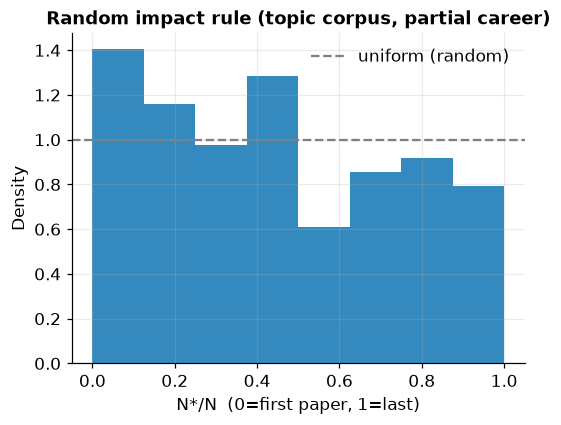

In [12]:
# 相対順位 N*/N のヒストグラム。一様分布（灰色の破線）に近ければランダムインパクトルールが成り立つ。
plt.figure(figsize=(5, 4))
plt.hist(peak_rank, bins=8, range=(0, 1), density=True, color='#348ABF')
plt.axhline(1.0, color='gray', ls='--', label='uniform (random)')
plt.xlabel('N*/N  (0=first paper, 1=last)'); plt.ylabel('Density'); plt.legend()
plt.title('Random impact rule (topic corpus, partial career)'); plt.tight_layout()
plt.savefig(f'{OUT_DIR}/03_random_impact_rule.pdf'); plt.show()


**結果の見方**: `N*/N` のヒストグラムが、灰色の破線（一様分布）とおおむね平ら（フラット）に重なっていれば、ランダムインパクトルールが成り立っていると読めます。棒の高さに多少のばらつきはあっても、特定の位置に鋭いピークが立たない点が重要です。

### 3-2. 完全ランダムな著者の全業績で見る（完全版）

§3-1 は「バクテリオファージ・トピック内の論文だけ」を見たため、各著者は**部分キャリア**でした（本来は各著者の全業績が必要）。ここでは元論文に忠実に、**OpenAlexから完全ランダムに著者を抽出し、その全業績**でルールを確かめます。トピックに依存しないベースラインです。

- 著者: `works_count >= 20` の著者を `sample`（seed固定で再現可能）でランダム抽出
- データ: 各著者の全 Works を `data/career/paper_authors.parquet` に保存済み（無ければ Release から取得）
- 指標: 全業績なので最高 **FWCI** の論文を最大ヒットとし、被引用の打ち切りを避けるため初出1960〜最終2020年の著者に限定

> 取得は重い（数千著者 × API）ので、**取得ロジックは末尾の付録セル**にまとめてあります（既定では実行せずキャッシュを読みます）。

authors=407 | mean=0.507 (uniform~0.5) | KS p=0.299


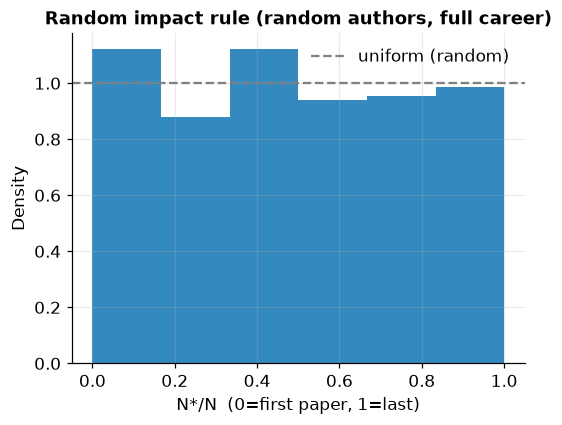

In [13]:
# 取得済みの「ランダム著者の全業績」を読み込む（作り方は末尾の付録セル参照）。
careers = pd.read_parquet('data/career/paper_authors.parquet').fillna(0)

MIN_WORKS = 20                                  # 解析対象の最低論文数
CAREER_YEAR_MIN, CAREER_YEAR_MAX = 1960, 2020   # 被引用の打ち切りを避けるキャリア範囲

# 各著者で「最大ヒット（最高FWCIの論文）の出版順の相対位置」を求め、一様分布かを KS検定で確かめる。
peak_rank_full = []
rng = np.random.default_rng(0)
for _, career in careers.groupby('author_id'):
    career = career.drop_duplicates('work_id').dropna(subset=['publication_year'])
    if len(career) < MIN_WORKS:
        continue
    years = career['publication_year'].to_numpy()
    if years.min() < CAREER_YEAR_MIN or years.max() > CAREER_YEAR_MAX:
        continue
    # 同年内の順序依存を消すため、シャッフルしてから年で安定ソート
    career = career.iloc[rng.permutation(len(career))].sort_values('publication_year', kind='stable')
    scores = career['fwci'].to_numpy(dtype=float)
    peak_idx = rng.choice(np.flatnonzero(scores == scores.max()))   # 同点はランダムに1本
    peak_rank_full.append((peak_idx + 0.5) / (len(career) - 1))     # 出版順の相対位置

peak_rank_full = np.array(peak_rank_full)
ks = stats.kstest(peak_rank_full, 'uniform')
print(f'authors={len(peak_rank_full)} | mean={peak_rank_full.mean():.3f} (uniform~0.5) | KS p={ks.pvalue:.3f}')

plt.figure(figsize=(5, 4))
plt.hist(peak_rank_full, bins=6, range=(0, 1), density=True, color='#348ABF')
plt.axhline(1.0, color='gray', ls='--', label='uniform (random)')
plt.xlabel('N*/N  (0=first paper, 1=last)'); plt.ylabel('Density'); plt.legend()
plt.title('Random impact rule (random authors, full career)'); plt.tight_layout()
plt.savefig(f'{OUT_DIR}/03_random_impact_rule_full.pdf'); plt.show()

**結果の見方**: トピックに縛られず OpenAlex から**ランダム抽出した著者の全業績**で見ると、対象は **407人**、平均 `N*/N` は **0.507** と 0.5（一様分布）にほぼ一致し、KS検定の **p値は 0.299** で一様性は棄却されません。§3-1 の部分キャリア版より 0.5 に近く、**ランダムインパクトルールがよりきれいに成り立ち**ます。「大器晩成型」も「若くしてピーク型」も特別ではなく、最高傑作はキャリアのどこにでも等確率で現れる — Sinatra et al. (2016) の主張が、独立に抽出したデータでも再現された、ということです。

### 3-2b. 元論文 Fig. 1 D–E の再現（Sinatra et al. 2016）

§3-2 で使った「ランダム著者の全業績」データを使って、元論文 **Sinatra, Wang, Deville, Song & Barabási, "Quantifying the evolution of individual scientific impact," _Science_ 354, aad0185 (2016)** の Fig. 1 D–E に相当する2枚を、自分のデータから描き直します。

- **左（D）**: 最大ヒットが「何本目の論文か」= 絶対順位 $N^*$ の分布 $P(N^*)$。実データ (Data) と、ヒット位置を一様ランダムに置き直した対照 (Randomized) を重ね、両者が重なれば「出現位置に時間的な偏りがない」ことを示します。
- **右（E）**: 相対順位 $N^*/N$ の**相補累積分布** $P(\geq N^*/N)$ を、生産性（総論文数 $N$）の3分位で low/mid/high に分けて描きます。3群が連続一様分布の目安線 $1-N^*/N$ に近ければ、**多作・寡作によらずランダムインパクトルールが成り立つ**ことを意味します。挿入図は「実測密度 ÷ 一様(=1)」の比で、1付近で平らなら一様分布と一致します。



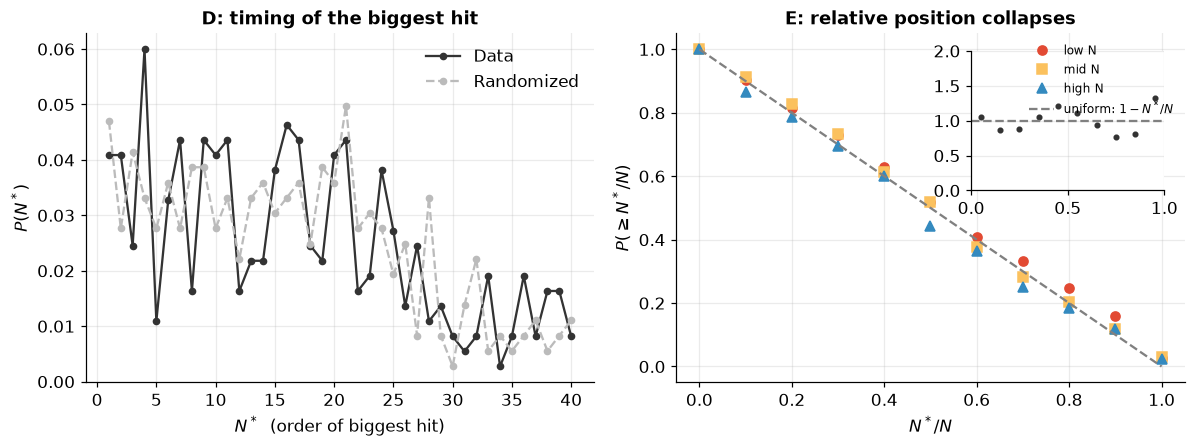

In [14]:
# §3-2 と同じ careers・同じ抽出条件で、各著者の「最大ヒットの出版順 N*」と「総論文数 N」を集める。
rng = np.random.default_rng(0)
Nstar, Ntot = [], []                        # Nstar=最大ヒットの順位(1始まり), Ntot=総論文数N
for _, career in careers.groupby('author_id'):
    career = career.drop_duplicates('work_id').dropna(subset=['publication_year'])
    if len(career) < MIN_WORKS:
        continue
    yr = career['publication_year'].to_numpy()
    if yr.min() < CAREER_YEAR_MIN or yr.max() > CAREER_YEAR_MAX:
        continue
    # 同年内の順序依存を消すためシャッフル→年で安定ソート（§3-2と同じ手順）
    career = career.iloc[rng.permutation(len(career))].sort_values('publication_year', kind='stable')
    scores = career['fwci'].to_numpy(dtype=float)
    peak_idx = rng.choice(np.flatnonzero(scores == scores.max()))   # 最高FWCIの論文（同点はランダム1本）
    Nstar.append(peak_idx + 1); Ntot.append(len(career))
Nstar = np.array(Nstar); Ntot = np.array(Ntot)
rel = Nstar / Ntot                          # 相対順位 N*/N ∈ (0,1]

# 対照(Randomized): 各著者で最大ヒットの位置を一様ランダムに置く（＝出版順の情報を壊した仮想キャリア）
rand_Nstar = np.array([rng.integers(1, n + 1) for n in Ntot])

# --- Panel D: 最大ヒットの絶対順位 N* の分布 P(N*)（Data vs Randomized）---
bins = np.arange(1, 42)                      # N*=1..40 を1本刻みでビン化
centers = bins[:-1]
pD_data, _ = np.histogram(Nstar, bins=bins, density=True)
pD_rand, _ = np.histogram(rand_Nstar, bins=bins, density=True)

# --- Panel E: 相対順位の相補累積分布 P(>=N*/N) を、生産性Nで3群に分けて描く ---
# 総論文数Nの3分位で low/mid/high に分割し、各群のCCDFが同じ直線(一様分布)に重なるかを見る。
q = np.quantile(Ntot, [1/3, 2/3])
groups = [('low N',   Ntot <= q[0]),
          ('mid N',  (Ntot > q[0]) & (Ntot <= q[1])),
          ('high N',  Ntot > q[1])]
xs = np.linspace(0, 1, 11)
ccdf = lambda v: np.array([(v >= x).mean() for x in xs])   # P(>=x): x以上の割合

fig, (axD, axE) = plt.subplots(1, 2, figsize=(11, 4.2))
# D: 実データと一様ランダム対照。重なれば出現位置に時間的な偏りが無い。
axD.plot(centers, pD_data, '-o', color='#333333', ms=4, label='Data')
axD.plot(centers, pD_rand, '--o', color='#bbbbbb', ms=4, label='Randomized')
axD.set_xlabel('$N^*$  (order of biggest hit)'); axD.set_ylabel('$P(N^*)$')
axD.set_title('D: timing of the biggest hit'); axD.legend()

# E: 生産性3群のCCDFと、一様分布の理論線 1 - N*/N。
for (lab, mask), mk, cc in zip(groups, ['o', 's', '^'], ['#E24A33', '#FBC15E', '#348ABF']):
    axE.plot(xs, ccdf(rel[mask]), mk, color=cc, ms=6, label=lab)
axE.plot(xs, 1 - xs, '--', color='gray', label='uniform: $1-N^*/N$')
axE.set_xlabel('$N^*/N$'); axE.set_ylabel('$P(\\geq N^*/N)$')
axE.set_title('E: relative position collapses'); axE.legend(fontsize=8)
# 挿入図: 実測密度 ÷ 一様(=1) の比。1付近で平らなら一様分布と一致。
axins = axE.inset_axes([0.58, 0.55, 0.38, 0.4])
dens, edges = np.histogram(rel, bins=10, range=(0, 1), density=True)
axins.plot((edges[:-1] + edges[1:]) / 2, dens, 'o', color='#333333', ms=3)
axins.axhline(1.0, color='gray', ls='--'); axins.set_xlim(0, 1); axins.set_ylim(0, 2)
fig.tight_layout(); fig.savefig(f'{OUT_DIR}/03_random_impact_rule_sinatra_DE.pdf'); plt.show()


**結果の見方**: 左 (D) は Data と Randomized がほぼ重なり、最大ヒットの出版順に系統的な偏りがないことを示します（低順位側にゆるやかな山ができるのは、長いキャリアほど人数が少なく $N^*$ が大きい値を取りにくいためで、Randomized でも同じ形になります）。右 (E) では、論文数で分けた3群 (low/mid/high N) がいずれも一様分布の目安線 $1-N^*/N$ にほぼ乗り、挿入図の比も1付近で平ら — **生産性に関係なく、最高傑作はキャリアのどこにでも等確率で現れる**という元論文 (Sinatra et al. 2016) の主眼を、私たち自身のデータで独立に再現できています。細部（マーカー形状・群分けの基準）は原図と異なりますが、**元図そのものを転載せずに同じ主張を示せている**点が重要です。

## 4. 初期キャリア特徴量と将来アウトカム

ここからは「**キャリア初期の数年間の姿から、将来の活躍を予測できるか**」を扱います。各著者について、最初の出版年から `EARLY_YEARS` 年間を「初期（early window）」とし、その期間の特徴量を作ります。特徴量は大きく2種類 — **貢献**（論文数・被引用・H-index・著者順位）と **研究環境**（共著者数・国際共著の割合・所属機関の多様性）です。そして初期より後のすべてを「将来アウトカム」として、将来の論文数・被引用・H-index を集計します。

In [15]:
EARLY_YEARS = 3
MIN_EARLY_PAPERS = 3

# 各著者のキャリア年齢（最初の出版年からの経過年）を計算し、初期 / 将来 に分ける。
paper_authors['first_year'] = paper_authors.groupby('author_id')['publication_year'].transform('min')
paper_authors['career_age'] = paper_authors['publication_year'] - paper_authors['first_year']
early = paper_authors[paper_authors['career_age'] < EARLY_YEARS]      # 初期 EARLY_YEARS 年間
future = paper_authors[paper_authors['career_age'] >= EARLY_YEARS]    # それ以降（将来アウトカム）

# 初期の特徴量: 貢献（論文数・引用・H-index・著者順位）と 研究環境（共著者数・国際共著・機関多様性）
features_df = early.groupby('author_id').agg(
    author_name=('author_name', 'first'), first_year=('first_year', 'first'),
    early_papers=('work_id', 'nunique'), early_citations=('cited_by_count', 'sum'),
    early_mean_citations=('cited_by_count', 'mean'), early_mean_coauthors=('coauthor_count', 'mean'),
    early_first_share=('author_position', lambda s: (s == 'first').mean()),
    early_last_share=('author_position', lambda s: (s == 'last').mean()))
features_df['early_h'] = early.groupby('author_id')['cited_by_count'].apply(h_index)
features_df['early_intl'] = early.groupby('author_id')['countries'].apply(
    lambda s: np.mean([len(set(x)) >= 2 for x in s]) if len(s) else np.nan)
features_df['early_inst_div'] = early.groupby('author_id')['institutions'].apply(
    lambda s: len({i for lst in s for i in lst}))

# 将来アウトカム（early以降の論文数・引用・H-index）
future_df = future.groupby('author_id').agg(
    future_papers=('work_id', 'nunique'), future_citations=('cited_by_count', 'sum'))
future_df['future_h'] = future.groupby('author_id')['cited_by_count'].apply(h_index)

features_df = (features_df.join(future_df)
              .fillna({'future_papers': 0, 'future_citations': 0, 'future_h': 0}).reset_index())
features_df = features_df[features_df['early_papers'] >= MIN_EARLY_PAPERS]
print('modelable authors:', len(features_df))
display(features_df.sort_values('future_h', ascending=False).head(10))


modelable authors: 12191


,author_id,author_name,first_year,early_papers,early_citations,early_mean_citations,early_mean_coauthors,early_first_share,early_last_share,early_h,early_intl,early_inst_div,future_papers,future_citations,future_h
90971,https://openalex.org/A5056568447,Rob Lavigne,2003,6,362,60.333333,5.666667,0.666667,0.000000,5,0.000000,1,314.0,20486.0,82.0
9596,https://openalex.org/A5006019718,Matthew B. Sullivan,2002,3,1214,404.666667,3.333333,0.333333,0.000000,3,0.000000,2,181.0,23711.0,72.0
137140,https://openalex.org/A5084974249,Curtis A. Suttle,1990,5,1247,249.400000,1.400000,1.000000,0.000000,3,0.000000,1,150.0,20607.0,70.0
182135,https://openalex.org/A5111590892,Roger W. Hendrix,1971,3,626,208.666667,2.000000,0.333333,0.000000,3,0.000000,1,147.0,15562.0,64.0
56716,https://openalex.org/A5035240489,Eugene V. Koonin,1989,3,831,277.000000,3.000000,0.000000,0.333333,3,0.000000,2,178.0,16255.0,64.0
45945,https://openalex.org/A5028591015,Mart Krupovìč,2006,8,514,64.250000,2.250000,0.875000,0.000000,8,0.125000,3,210.0,13995.0,61.0
127920,https://openalex.org/A5079257651,Sylvain Moineau,1991,7,275,39.285714,2.000000,0.857143,0.000000,4,0.285714,2,198.0,20300.0,61.0
148068,https://openalex.org/A5091702193,Patrick Forterre,1989,3,145,48.333333,3.666667,0.000000,0.000000,3,0.000000,2,123.0,9445.0,57.0
21747,https://openalex.org/A5013600763,Simon Roux,2011,7,779,111.285714,3.428571,1.000000,0.000000,4,0.000000,4,160.0,19413.0,55.0
42608,https://openalex.org/A5026525836,Forest Rohwer,2000,6,1923,320.500000,3.833333,0.666667,0.333333,5,0.166667,4,99.0,21189.0,54.0


**結果の見方**: 初期に3本以上論文を出した **12,191人** が予測モデルの対象です。表は将来 H-index の高い順で、上位には §2 のリーダーボード上位者（Rob Lavigne, Matthew B. Sullivan など）が並び、`early_*`（初期の特徴量）と `future_*`（将来の成果）が横に並んでいます。次の §5 では、この `early_*` だけを入力に `future_h` を予測します。

## 5. 将来 H-index を Random Forest で予測する

初期の特徴量だけを入力に、将来の H-index を **Random Forest**（多数の決定木を組み合わせる機械学習手法）で予測します。データを訓練用7割・テスト用3割に分け、テスト側での予測精度（MAE・R²）と、**どの初期指標が予測に効くか**（特徴量重要度）を見ます。

MAE: 2.06
R2 : 0.202


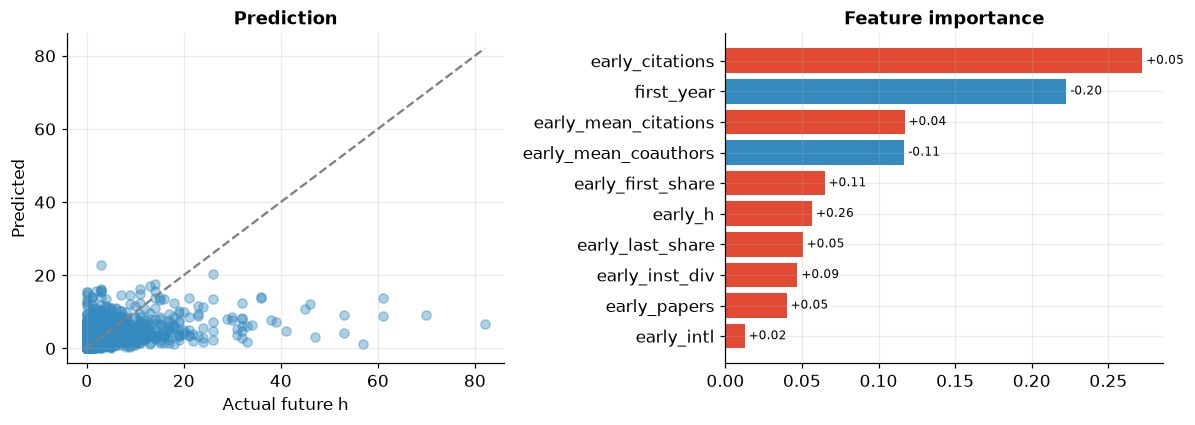

In [16]:
# 入力に使う初期特徴量（early_* と first_year）。目的変数は future_h（初期より後のH-index）。
features = ['first_year', 'early_papers', 'early_citations', 'early_mean_citations', 'early_h',
            'early_mean_coauthors', 'early_intl', 'early_inst_div', 'early_first_share', 'early_last_share']

# 訓練7割・テスト3割に分割（random_state固定で再現可能）。
train, test = train_test_split(features_df, test_size=0.3, random_state=42)
# 欠損は中央値で補完 → Random Forest 回帰。木を300本、葉の最小サンプル3で過学習を抑える。
model = make_pipeline(SimpleImputer(strategy='median'),
                      RandomForestRegressor(n_estimators=300, min_samples_leaf=3, random_state=42))
model.fit(train[features], train['future_h'])
pred = model.predict(test[features])                     # テストデータで将来H-indexを予測
print('MAE:', round(mean_absolute_error(test['future_h'], pred), 3))   # 平均絶対誤差（小さいほど良い）
print('R2 :', round(r2_score(test['future_h'], pred), 3))              # 決定係数（1に近いほど良い）

# 特徴量の重要度と、future_h との相関の符号（importanceは強さだけで向きを持たないため相関で補う）
importance = pd.DataFrame({'feature': features,
    'importance': model.named_steps['randomforestregressor'].feature_importances_})
importance['corr'] = [features_df[f].corr(features_df['future_h']) for f in features]
importance = importance.sort_values('importance')

# 左: 予測 vs 実測（対角線が完全予測）, 右: 特徴量重要度（棒の色=相関の符号, 数値=相関係数）。
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(test['future_h'], pred, alpha=0.4, color='#348ABF')
lim = max(test['future_h'].max(), pred.max())
axes[0].plot([0, lim], [0, lim], '--', color='gray')
axes[0].set_xlabel('Actual future h'); axes[0].set_ylabel('Predicted'); axes[0].set_title('Prediction')
colors = ['#E24A33' if c >= 0 else '#348ABF' for c in importance['corr']]   # 赤=正の相関 / 青=負の相関
axes[1].barh(importance['feature'], importance['importance'], color=colors)
for y, (imp, c) in enumerate(zip(importance['importance'], importance['corr'])):
    axes[1].text(imp, y, f' {c:+.2f}', va='center', fontsize=8)
axes[1].set_title('Feature importance')
fig.tight_layout(); fig.savefig(f'{OUT_DIR}/03_researcher_future_prediction.pdf'); plt.show()


**結果の見方**: テストデータでの平均絶対誤差（**MAE）は約 2.06**、決定係数 **R² は約 0.20**。初期数年のデータだけで将来 H-index の**2割ほどのばらつきを説明**でき、予測は平均して H-index にして約2ずれる、という水準です。完璧ではありませんが、キャリア初期に将来の兆しが確かに表れていることを示します。左の散布図（予測 vs 実測、対角線が完全予測）では高H-index側で予測が控えめになる傾向が、右の棒グラフでは特徴量重要度が見えます。注記の符号（+/−）は将来H-indexとの相関の向きで、`early_h` や `early_citations` など初期のインパクト系指標が正に効くことが読み取れます。

### 5-1. 早期業績と将来アウトカムの相関（r, p値）

参照: ScisciJP 4-H-index。初期と将来の散布図に **Pearson r・p値** を注記します（歪み対策に平方根変換、対角線はy=x）。因果ではなく相関構造の確認です。

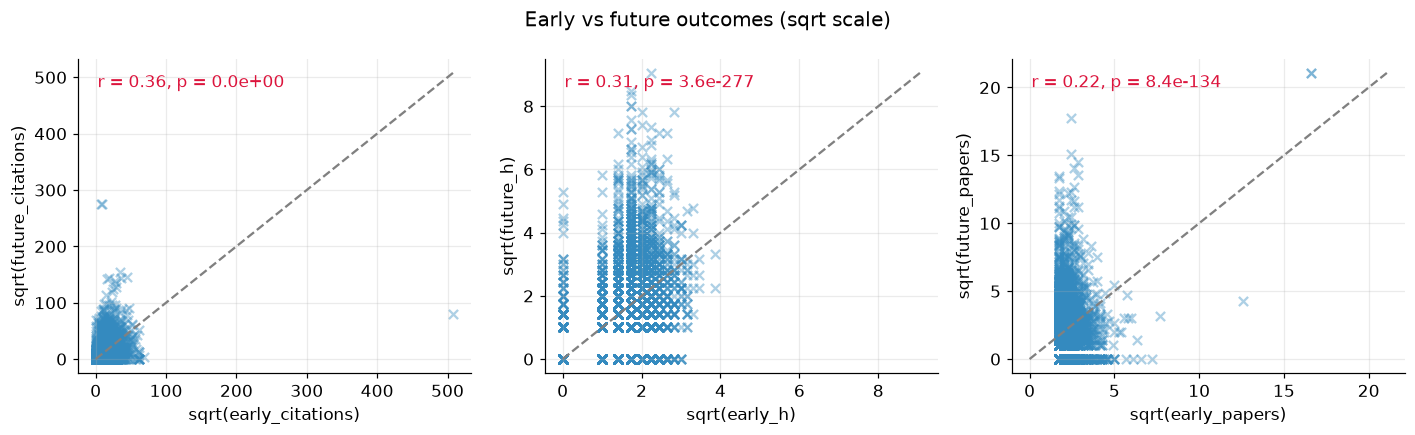

In [17]:
from scipy.stats import pearsonr
pairs = [('early_citations', 'future_citations'), ('early_h', 'future_h'), ('early_papers', 'future_papers')]
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (xcol, ycol) in zip(axes, pairs):
    x = np.sqrt(features_df[xcol].clip(lower=0)); y = np.sqrt(features_df[ycol].clip(lower=0))  # 歪み対策に平方根変換
    ax.scatter(x, y, marker='x', alpha=0.4, color='#348ABF')
    lim = max(x.max(), y.max()); ax.plot([0, lim], [0, lim], '--', color='gray')
    r, p = pearsonr(x, y)
    ax.text(0.05, 0.95, f'r = {r:.2f}, p = {p:.1e}', transform=ax.transAxes, va='top', color='crimson')
    ax.set_xlabel(f'sqrt({xcol})'); ax.set_ylabel(f'sqrt({ycol})')
fig.suptitle('Early vs future outcomes (sqrt scale)')
fig.tight_layout(); fig.savefig(f'{OUT_DIR}/03_early_future_correlation.pdf'); plt.show()


**結果の見方**: 初期と将来の対応する指標（被引用・H-index・論文数）を散布図にし、Pearson の相関係数 r と p値を注記しています（歪みを抑えるため平方根軸、破線は y=x）。3つとも正の相関が明確で、**初期の実績が高い人ほど将来も高い**という一貫した構造が見えます。ただしこれは相関であって因果ではない点に注意 — 初期の成功が将来を「引き起こす」のか、才能や環境などの共通要因の反映なのかは、この図だけでは分かりません。

## 付録：ランダム著者の全業績データについて
§3-2 が読む `data/career/paper_authors.parquet` は、[01. OpenAlex API アクセス入門](01_openalex_api_access.ipynb) の付録「ランダム著者の全業績を取得する」で作成します。セットアップの `ensure_data(NAME, works=True, career=True)` が配布済みデータを自動取得するため、通常は再取得不要です。作り直したいときは 01 の付録セルで `REBUILD_CAREERS = True` にしてください。